In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for aesthetics
sns.set_theme(style="whitegrid")

# 1. Load the Titanic dataset (using the official online source URL)
df = pd.read_csv('Titanic.csv')

# 2. Basic Data Exploration
print("--- Dataset Information ---")
print(df.info())

print("\n--- Descriptive Statistics ---")
print(df.describe(include='all'))

# 3. Handle Missing Values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin'], inplace=True, errors='ignore')


df['FamilySize'] = df['SibSp'] + df['Parch']

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

--- Descriptive Statistics ---
        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN       

In [50]:
#Q1. Create a countplot to show the number of passengers by gender.


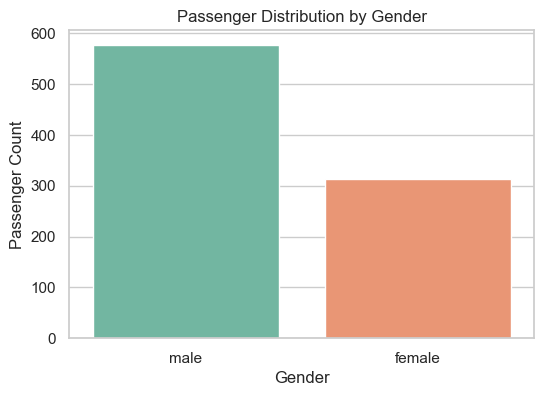

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sex', hue='Sex', palette='Set2', legend=False)
plt.title('Passenger Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.show()

In [20]:
#Interpretation: The visualization clearly shows that the number of male passengers on the Titanic significantly outnumbered female passengers (roughly double).

In [21]:
#Q2. Create a bar chart to show the number of passengers in each passenger class using different colors. 


D:\Lib\site-packages\IPython\core\inputtransformer2.py:675: UserWarning: `make_tokens_by_line` received a list of lines which do not have lineending markers ('\n', '\r', '\r\n', '\x0b', '\x0c'), behavior will be unspecified
  tokens_by_line = make_tokens_by_line(lines)


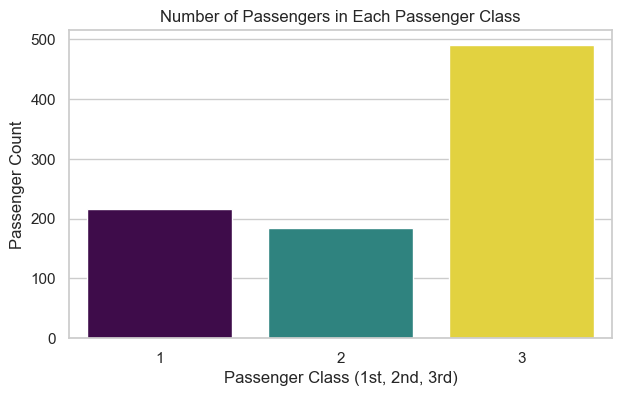

In [22]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Pclass', hue='Pclass', palette='viridis', legend=False)
plt.title('Number of Passengers in Each Passenger Class')
plt.xlabel('Passenger Class (1st, 2nd, 3rd)')
plt.ylabel('Passenger Count')
plt.show()

In [23]:
#Interpretation: Third-class (Pclass 3) had the largest portion of travelers by far, exceeding the first and second classes combined. This implies the majority of the ship's demographic consisted of lower-income or economy travelers.

In [24]:
#Q3. Create a histogram to show the distribution of passenger age. 


D:\Lib\site-packages\IPython\core\inputtransformer2.py:675: UserWarning: `make_tokens_by_line` received a list of lines which do not have lineending markers ('\n', '\r', '\r\n', '\x0b', '\x0c'), behavior will be unspecified
  tokens_by_line = make_tokens_by_line(lines)


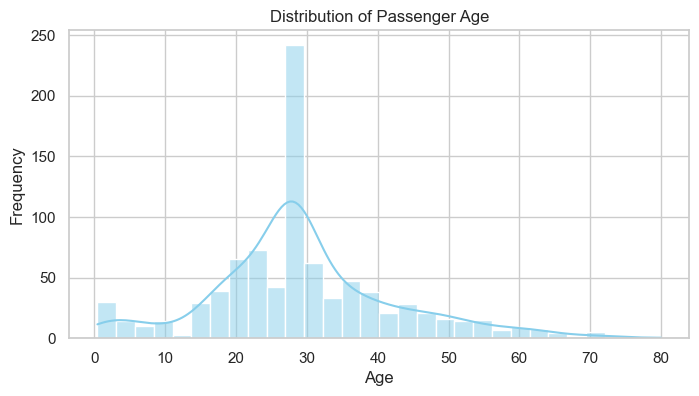

In [25]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', kde=True, color='skyblue', bins=30)
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [26]:
#Interpretation: The age distribution is roughly bell-shaped, peaking heavily between the ages of 20 and 40. There is also a small spike on the far left, representing a noticeable population of young children and infants on board.

In [27]:
#Q4. Create a boxplot to detect outliers in the fare column.



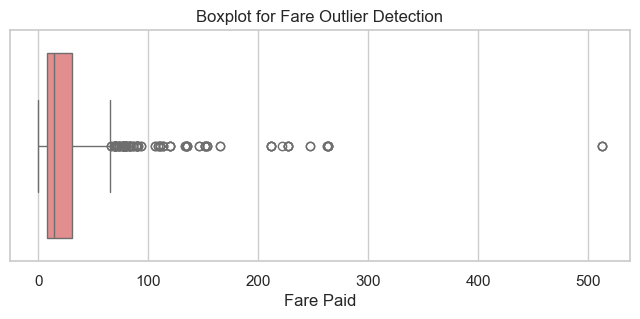

In [28]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='Fare', color='lightcoral')
plt.title('Boxplot for Fare Outlier Detection')
plt.xlabel('Fare Paid')
plt.show()

In [29]:
#Interpretation: The boxplot indicates a heavy concentration of data points tightly clustered under $50. However, there are numerous data points extending far to the right, including extreme outliers paying over $500, confirming massive wealth disparity among passengers.

In [30]:
#Q5. Create a scatterplot to
#a. show the relationship between age and fare.



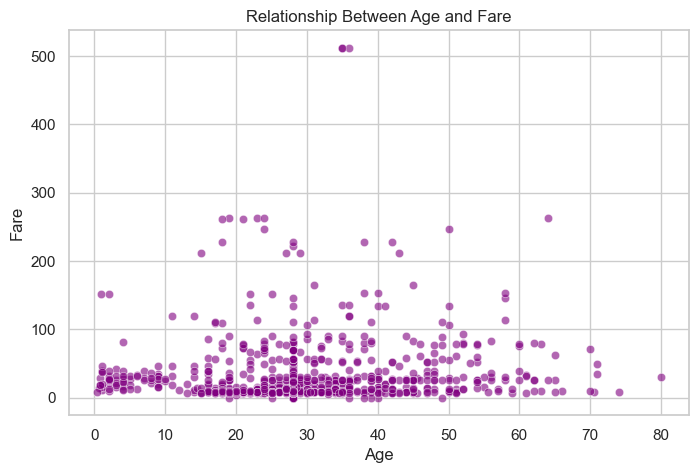

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Fare', alpha=0.6, color='purple')
plt.title('Relationship Between Age and Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

In [32]:
#Interpretation: There isn't a strong visible linear correlation between age and fare. Passengers of almost all age groups bought cheaper tickets (under $50). However, the ultra-premium tickets ($200+) were purchased almost exclusively by adults.

In [33]:
#b. analyze the relationship between family size (SibSp + Parch) and fare

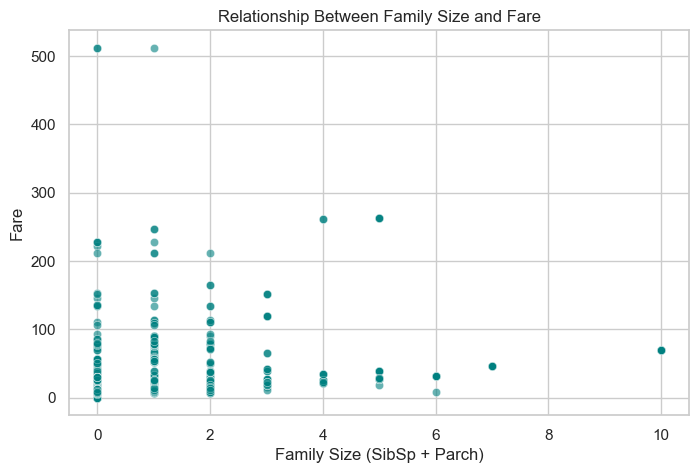

In [34]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='FamilySize', y='Fare', alpha=0.6, color='teal')
plt.title('Relationship Between Family Size and Fare')
plt.xlabel('Family Size (SibSp + Parch)')
plt.ylabel('Fare')
plt.show()

In [35]:
#Interpretation: Solitary travelers (FamilySize = 0) or those traveling in small clusters (1 to 3 family members) spanned the entire spectrum of fares, including the highest ticket brackets. Conversely, large families (5 or more members) consistently paid lower, budget fares.

In [36]:
#Q6. Create a countplot to show survival count by gender. 


D:\Lib\site-packages\IPython\core\inputtransformer2.py:675: UserWarning: `make_tokens_by_line` received a list of lines which do not have lineending markers ('\n', '\r', '\r\n', '\x0b', '\x0c'), behavior will be unspecified
  tokens_by_line = make_tokens_by_line(lines)


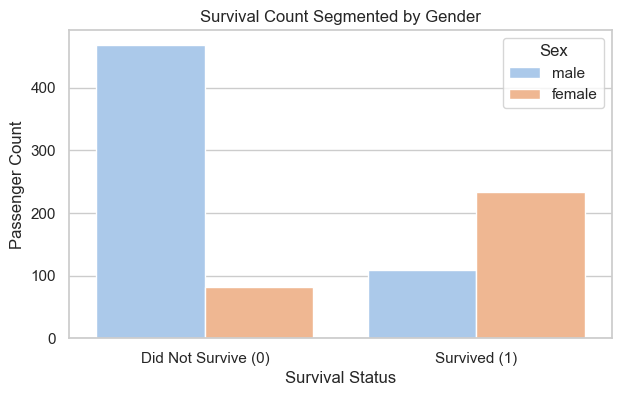

In [37]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Survived', hue='Sex', palette='pastel')
plt.title('Survival Count Segmented by Gender')
plt.xticks([0, 1], ['Did Not Survive (0)', 'Survived (1)'])
plt.xlabel('Survival Status')
plt.ylabel('Passenger Count')
plt.show()

In [38]:
#Interpretation: Despite males making up the vast majority of people on board, the absolute number of female survivors was significantly higher. This starkly demonstrates the societal application of the "women and children first" maritime protocol.

In [39]:
#Q7. Create a bar chart to show survival by passenger class. 


D:\Lib\site-packages\IPython\core\inputtransformer2.py:675: UserWarning: `make_tokens_by_line` received a list of lines which do not have lineending markers ('\n', '\r', '\r\n', '\x0b', '\x0c'), behavior will be unspecified
  tokens_by_line = make_tokens_by_line(lines)


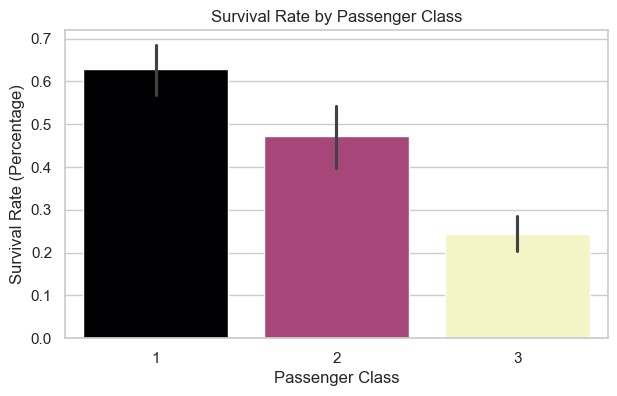

In [40]:
plt.figure(figsize=(7, 4))
# Using a barplot with Survived as y calculated as a mean effectively shows survival rate
sns.barplot(data=df, x='Pclass', y='Survived', hue='Pclass', palette='magma', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (Percentage)')
plt.show()

In [41]:
#Interpretation: There is a direct, stepwise drop in survival rates based on social status. First-class passengers had a survival rate near 60%, whereas less than 25% of third-class passengers survived.

In [42]:
#Q8. Create a heatmap to show correlation between numerical variables. 


D:\Lib\site-packages\IPython\core\inputtransformer2.py:675: UserWarning: `make_tokens_by_line` received a list of lines which do not have lineending markers ('\n', '\r', '\r\n', '\x0b', '\x0c'), behavior will be unspecified
  tokens_by_line = make_tokens_by_line(lines)


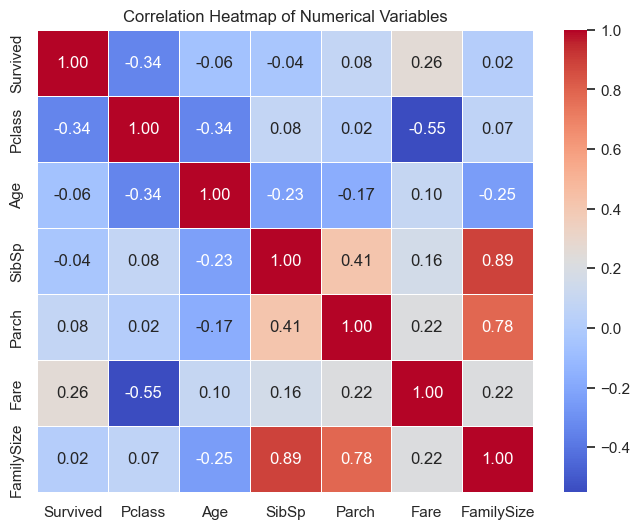

In [43]:
plt.figure(figsize=(8, 6))
numeric_cols = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']]
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [44]:
#Interpretation: The strongest negative correlation sits between Pclass and Fare (-0.55), indicating lower-class numbers corresponded to much higher ticket costs. Additionally, Fare shows a mild positive correlation with survival, while Pclass shares a negative correlation with survival.

In [45]:
#Q9. Identify which passenger class paid the highest fare on average. 


D:\Lib\site-packages\IPython\core\inputtransformer2.py:675: UserWarning: `make_tokens_by_line` received a list of lines which do not have lineending markers ('\n', '\r', '\r\n', '\x0b', '\x0c'), behavior will be unspecified
  tokens_by_line = make_tokens_by_line(lines)


In [46]:
avg_fare_by_class = df.groupby('Pclass')['Fare'].mean()
print("Average Fare Paid per Class:")
print(avg_fare_by_class)

Average Fare Paid per Class:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [47]:
#Answer: First Class (Pclass 1) paid the highest average fare. Their average fare sat at roughly $84.15, compared to $20.66 for second class and $13.68 for third class.

In [48]:
#Q10. Write at least 5 insights from the dataset based on your visualizations.

In [49]:
'''Based on the visual patterns and metric comparisons generated through this analysis, we can conclude the following 5 definitive insights:  
Gender and Survival Bias: Women had a vastly superior chance of survival compared to men. Gender played one of the most critical roles in determining safety prioritization during the evacuation. 
    Socioeconomic Priority: Your ticket class largely dictated your survival outcome. First-class passengers were disproportionately rescued, while third-class passengers suffered the highest loss of life.
        Class vs. Cost Disparity: The dataset experiences heavy skewness regarding fare distribution. While first class charged a steep premium on average, third class provided highly compressed, cheap ticket pricing options to accommodate large passenger numbers. 
        Demographics of Travelers: The Titanic's main traveler demographic was comprised of young independent adults or couples between 20 and 40 years old.  
        Family Size Constraints: Large families traveling together were restricted purely to lower, budget-class configurations. Higher-end luxury suites were purchased exclusively by single travelers or pairs'''

"Based on the visual patterns and metric comparisons generated through this analysis, we can conclude the following 5 definitive insights:  \nGender and Survival Bias: Women had a vastly superior chance of survival compared to men. Gender played one of the most critical roles in determining safety prioritization during the evacuation. \n    Socioeconomic Priority: Your ticket class largely dictated your survival outcome. First-class passengers were disproportionately rescued, while third-class passengers suffered the highest loss of life.\n        Class vs. Cost Disparity: The dataset experiences heavy skewness regarding fare distribution. While first class charged a steep premium on average, third class provided highly compressed, cheap ticket pricing options to accommodate large passenger numbers. \n        Demographics of Travelers: The Titanic's main traveler demographic was comprised of young independent adults or couples between 20 and 40 years old.  \n        Family Size Constra